# E-commerce Customer Retention & Funnel Analysis (SQL)
**Author:** Jatin Kumar Puppala

## Business context
Cartwise (a fictional online store) doubled revenue in 2025, but most of that growth was
bought through paid acquisition. The leadership team wants to know whether the growth is
**healthy**: do new customers come back, which channels bring valuable customers, and
where is the website losing sales?

**Questions**
1. How are revenue, orders and AOV trending?
2. How well do we retain customers, and did the *Cartwise Plus* free-shipping membership
   (launched 1 Mar 2025) help?
3. Which acquisition channels deliver customers with the highest long-term value?
4. Where in the purchase funnel do shoppers drop off?
5. Who are our most valuable customers, and who are we at risk of losing?

All analysis is written in **SQL** (`/sql` folder, SQLite dialect). Python only runs the
queries and draws the charts.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))
from sql_runner import connect, load_queries, run  # noqa: E402

IMG = ROOT / "images"
IMG.mkdir(exist_ok=True)
con = connect()          # opens data/cartwise.db and (re)creates the clean views in 02_views.sql

PRIMARY, SECONDARY, MUTED, ALERT, GOOD = "#3d5a80", "#98c1d9", "#c5cdd6", "#d1495b", "#2a9d8f"
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "axes.spines.top": False, "axes.spines.right": False})
pct = mtick.PercentFormatter(100, decimals=0)
money = mtick.FuncFormatter(lambda v, _: f"${v / 1e3:,.0f}K")


def save(fig, name):
    fig.savefig(IMG / f"{name}.png", bbox_inches="tight", dpi=150)


def show_sql(file, name):
    print(f"-- {file} :: {name}\n" + load_queries(file)[name])

## 1. Data model and quality checks

```
customers 1───* orders 1───* order_items *───1 products
    └───────0..* web_events (session-level clickstream, 2025)
```
The checks below come from `sql/01_data_quality_checks.sql`.

In [2]:
run(con, "01_data_quality_checks.sql", "row_counts")

,table_name,row_count
0,customers,12000
1,products,200
2,orders,24836
3,order_items,49707
4,web_events,134429


In [3]:
run(con, "01_data_quality_checks.sql", "orphan_and_null_checks")

,check_name,issues
0,orders without a valid customer,0
1,orders without any line items,0
2,order lines with non-positive quantity or price,0
3,orders dated before customer first_seen_date,0


In [4]:
run(con, "01_data_quality_checks.sql", "test_account_impact")

,is_test_account,customers,orders,orders_per_customer
0,0,11988,24296,2.0
1,1,12,540,45.0


In [5]:
run(con, "01_data_quality_checks.sql", "duplicate_events")

,duplicate_rows,pct_of_events
0,1067,0.79


**What the checks found and how it was handled (in `02_views.sql`):**
* Referential integrity is clean: no orphan orders, empty orders or invalid prices.
* **12 internal test accounts** placed 540 fake orders, averaging **45 orders each**
  against 2 for real customers. Left in, they would inflate repeat-purchase and
  loyalty metrics. They are excluded in every view.
* **0.8% of web events are duplicates** (tracking tag fired twice). They are
  de-duplicated in `v_events` so funnel counts are not overstated.

## 2. Business performance overview

In [6]:
yearly = run(con, "03_kpi_overview.sql", "yearly_kpis")
yearly

,year,orders,active_customers,new_customers,returning_customers,net_revenue,avg_order_value,orders_per_customer
0,2024,8005,5224,5224,0,1507751.0,208.28,1.53
1,2025,15310,7712,6499,1213,2989387.0,216.48,1.99


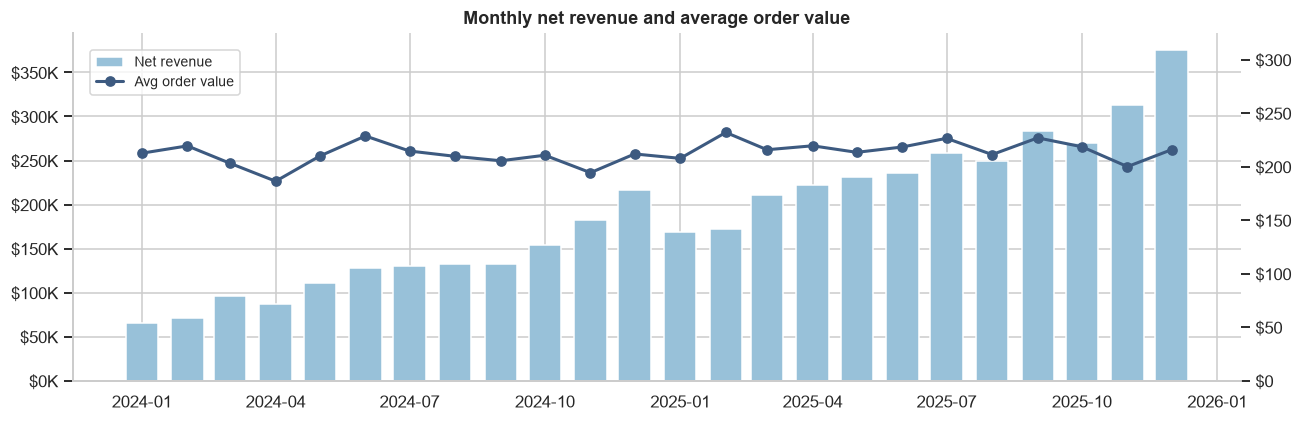

In [7]:
m = run(con, "03_kpi_overview.sql", "monthly_kpis")
m["order_month"] = pd.to_datetime(m["order_month"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(m["order_month"], m["net_revenue"], width=22, color=SECONDARY, label="Net revenue")
ax.yaxis.set_major_formatter(money)
ax2 = ax.twinx()
ax2.plot(m["order_month"], m["avg_order_value"], color=PRIMARY, marker="o", lw=2, label="Avg order value")
ax2.set_ylim(0, m["avg_order_value"].max() * 1.4)
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax2.grid(False)
ax.set_title("Monthly net revenue and average order value")
fig.legend(loc="upper left", bbox_to_anchor=(0.07, 0.88), fontsize=9)
fig.tight_layout()
save(fig, "01_monthly_revenue")
plt.show()

Revenue roughly **doubled** year over year with a stable AOV, so growth came from **more
customers and more orders per customer**, not bigger baskets. The next sections test how
sustainable that is.

## 3. Cohort retention

In [8]:
show_sql("04_cohort_retention.sql", "cohort_retention")

-- 04_cohort_retention.sql :: cohort_retention
WITH activity AS (               -- every month in which a customer purchased
    SELECT DISTINCT customer_id, order_month AS activity_month
    FROM v_orders
    WHERE status <> 'Cancelled'
),
cohort_size AS (
    SELECT cohort_month, COUNT(*) AS cohort_customers
    FROM v_customer_summary
    GROUP BY cohort_month
),
retention AS (
    SELECT  s.cohort_month,
            (CAST(strftime('%Y', a.activity_month) AS INTEGER) - CAST(strftime('%Y', s.cohort_month) AS INTEGER)) * 12
          + (CAST(strftime('%m', a.activity_month) AS INTEGER) - CAST(strftime('%m', s.cohort_month) AS INTEGER))
                                                    AS month_number,
            COUNT(DISTINCT a.customer_id)           AS active_customers
    FROM activity a
    JOIN v_customer_summary s ON s.customer_id = a.customer_id
    GROUP BY 1, 2
)
SELECT  r.cohort_month,
        cs.cohort_customers,
        r.month_number,
        r.active_customers,
      

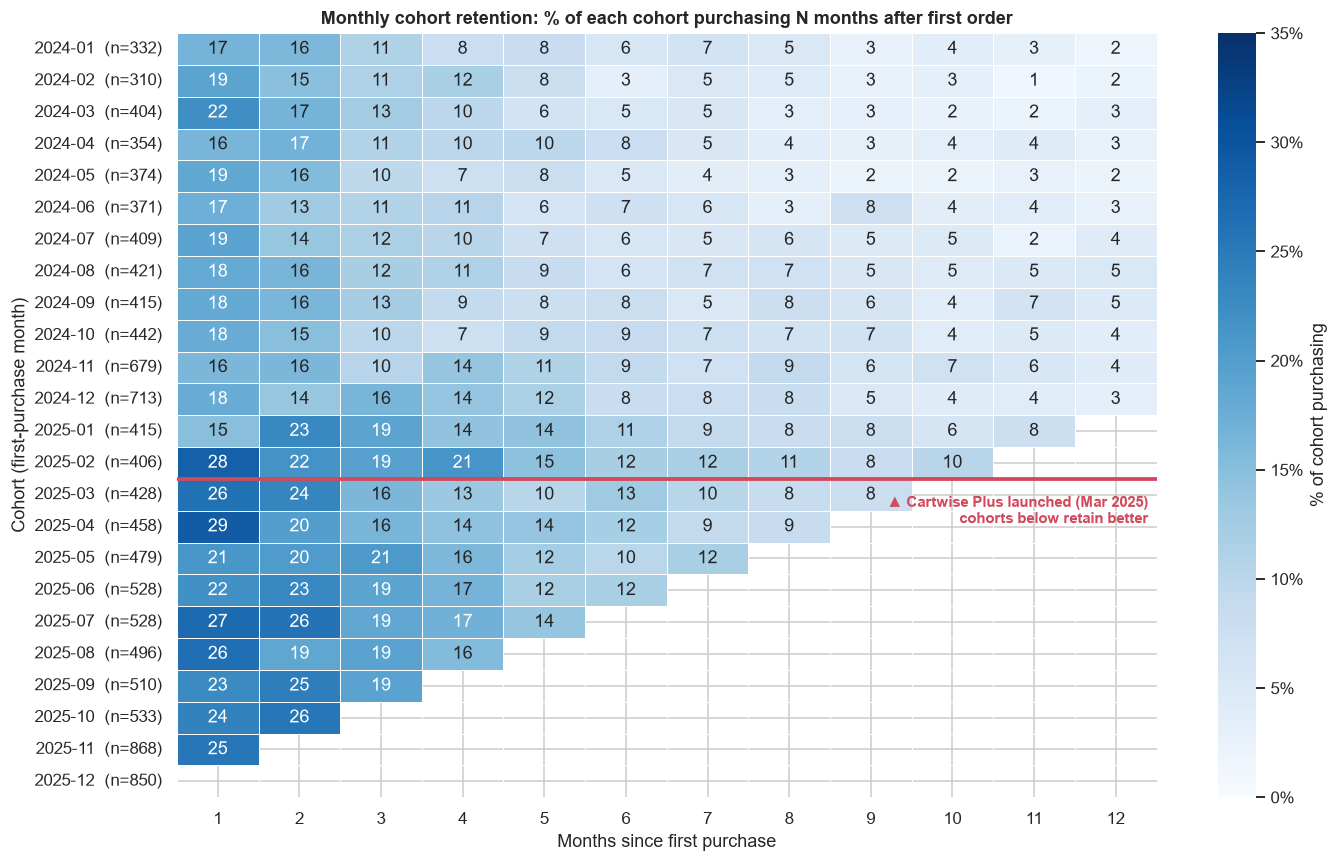

In [9]:
coh = run(con, "04_cohort_retention.sql", "cohort_retention")
coh["cohort_month"] = pd.to_datetime(coh["cohort_month"]).dt.strftime("%Y-%m")
matrix = coh.pivot(index="cohort_month", columns="month_number", values="retention_rate")
sizes = coh.drop_duplicates("cohort_month").set_index("cohort_month")["cohort_customers"]
matrix = matrix.loc[:, 1:12]   # month 0 is always 100%

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(matrix * 100, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=35,
            cbar_kws={"label": "% of cohort purchasing", "format": pct}, linewidths=0.4, ax=ax)
ax.set_yticklabels([f"{c}  (n={sizes[c]:,})" for c in matrix.index], rotation=0)
launch_row = list(matrix.index).index("2025-03")
ax.axhline(launch_row, color=ALERT, lw=2.5)
ax.text(11.9, launch_row + 0.5, "▲ Cartwise Plus launched (Mar 2025)\ncohorts below retain better",
        color=ALERT, ha="right", va="top", fontsize=9.5, fontweight="bold")
ax.set(title="Monthly cohort retention: % of each cohort purchasing N months after first order",
       xlabel="Months since first purchase", ylabel="Cohort (first-purchase month)")
fig.tight_layout()
save(fig, "02_cohort_retention_heatmap")
plt.show()

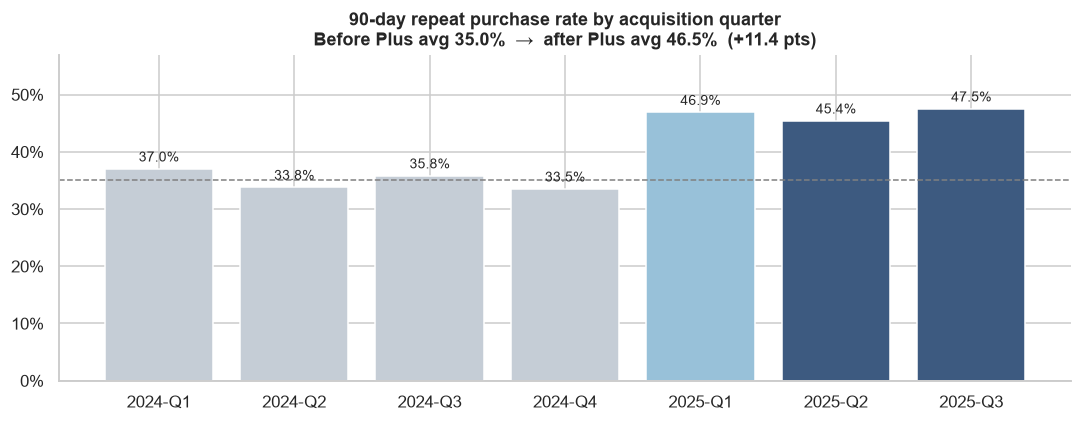

,cohort_quarter,new_customers,repeat_90d,repeat_rate_90d_pct,period
0,2024-Q1,1046,387,37.0,Before Cartwise Plus
1,2024-Q2,1099,372,33.8,Before Cartwise Plus
2,2024-Q3,1245,446,35.8,Before Cartwise Plus
3,2024-Q4,1834,615,33.5,Before Cartwise Plus
4,2025-Q1,1249,586,46.9,Launch quarter
5,2025-Q2,1465,665,45.4,After Cartwise Plus
6,2025-Q3,1534,728,47.5,After Cartwise Plus


In [10]:
rr = run(con, "04_cohort_retention.sql", "repeat_rate_by_quarter")
colors = rr["period"].map({"Before Cartwise Plus": MUTED, "Launch quarter": SECONDARY,
                           "After Cartwise Plus": PRIMARY})
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(rr["cohort_quarter"], rr["repeat_rate_90d_pct"], color=colors)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax.yaxis.set_major_formatter(pct)
ax.set_ylim(0, rr["repeat_rate_90d_pct"].max() * 1.2)
before = rr.loc[rr.period == "Before Cartwise Plus", "repeat_rate_90d_pct"].mean()
after = rr.loc[rr.period == "After Cartwise Plus", "repeat_rate_90d_pct"].mean()
ax.axhline(before, color="grey", ls="--", lw=1)
ax.set_title(f"90-day repeat purchase rate by acquisition quarter\n"
             f"Before Plus avg {before:.1f}%  →  after Plus avg {after:.1f}%  (+{after - before:.1f} pts)")
fig.tight_layout()
save(fig, "03_repeat_rate_by_quarter")
plt.show()
rr

* Retention fades quickly: typically only **10–20%** of a cohort buys in any given later
  month, and the heatmap gets lighter as months pass.
* Cohorts acquired **after Cartwise Plus launched** repeat noticeably more often. The 90-day
  repeat rate rose from about 35% to about 46%. Q1 2025 also rose because those customers'
  90-day windows mostly fall after the launch.
* *Caveat:* this is a before/after comparison, not a controlled experiment. Q1 2025 vs
  Q1 2024 (same season) shows the same lift, which supports the effect being real rather
  than seasonal. A holdout test would confirm it.

## 4. Acquisition channel quality

In [11]:
show_sql("05_channel_performance.sql", "channel_quality")

-- 05_channel_performance.sql :: channel_quality
WITH second_orders AS (
    SELECT  s.customer_id,
            MIN(o.order_date) AS second_order_date
    FROM v_customer_summary s
    JOIN v_orders o
      ON o.customer_id = s.customer_id
     AND o.status <> 'Cancelled'
     AND o.order_date > s.first_order_date
    GROUP BY s.customer_id
),
rev_12m AS (                      -- revenue in each customer's first 365 days
    SELECT  s.customer_id,
            SUM(o.order_value) AS revenue_12m
    FROM v_customer_summary s
    JOIN v_completed_orders o
      ON o.customer_id = s.customer_id
     AND o.order_date < DATE(s.first_order_date, '+365 days')
    GROUP BY s.customer_id
)
SELECT  s.acquisition_channel,
        COUNT(*)                                                                        AS customers,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)                              AS pct_of_new_customers,
        -- 90-day repeat rate (customers with a full 90-day window

In [12]:
ch = run(con, "05_channel_performance.sql", "channel_quality")
ch

,acquisition_channel,customers,pct_of_new_customers,repeat_rate_90d_pct,avg_12m_revenue,avg_lifetime_orders
0,Referral,1227,10.5,63.3,607.22,2.91
1,Organic Search,2280,19.4,54.3,476.72,2.39
2,Email,1221,10.4,57.8,443.05,2.37
3,Paid Search,2595,22.1,45.5,375.73,1.93
4,Affiliate,934,8.0,35.4,311.97,1.57
5,Paid Social,3466,29.6,30.6,258.61,1.42


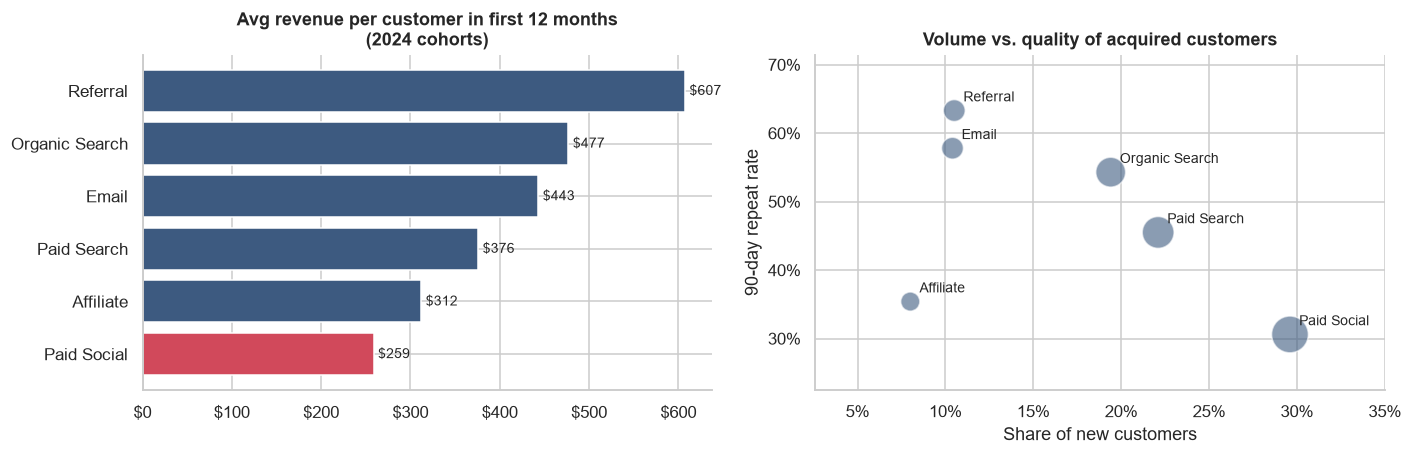

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
c = ch.sort_values("avg_12m_revenue")
colors = [ALERT if x == "Paid Social" else PRIMARY for x in c["acquisition_channel"]]
axes[0].barh(c["acquisition_channel"], c["avg_12m_revenue"], color=colors)
axes[0].bar_label(axes[0].containers[0], fmt="$%.0f", padding=3, fontsize=9)
axes[0].set(title="Avg revenue per customer in first 12 months\n(2024 cohorts)", xlabel="")
axes[0].xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

axes[1].scatter(ch["pct_of_new_customers"], ch["repeat_rate_90d_pct"],
                s=ch["customers"] / 6, color=PRIMARY, alpha=0.6, edgecolor="white")
for _, r in ch.iterrows():
    axes[1].annotate(r.acquisition_channel, (r.pct_of_new_customers, r.repeat_rate_90d_pct),
                     xytext=(6, 6), textcoords="offset points", fontsize=9)
axes[1].xaxis.set_major_formatter(pct)
axes[1].yaxis.set_major_formatter(pct)
axes[1].set(title="Volume vs. quality of acquired customers",
            xlabel="Share of new customers", ylabel="90-day repeat rate")
axes[1].margins(0.25)
fig.tight_layout()
save(fig, "04_channel_quality")
plt.show()

**Paid Social is the largest acquisition channel (~30% of new customers) but the worst on
quality.** Its customers are about half as likely to repeat as Referral customers and are
worth **less than half** as much in their first year. Referral, Organic Search and Email
customers are the most valuable.

## 5. Conversion funnel (2025 web sessions)

In [14]:
show_sql("06_funnel_analysis.sql", "funnel_by_device")

-- 06_funnel_analysis.sql :: funnel_by_device
WITH session_steps AS (           -- one row per session with a 0/1 flag per funnel step
    SELECT  session_id,
            device,
            MAX(event_name = 'session_start')   AS s1_session,
            MAX(event_name = 'product_view')    AS s2_product_view,
            MAX(event_name = 'add_to_cart')     AS s3_add_to_cart,
            MAX(event_name = 'begin_checkout')  AS s4_checkout,
            MAX(event_name = 'purchase')        AS s5_purchase
    FROM v_events
    GROUP BY session_id, device
)
SELECT  device,
        SUM(s1_session)                                                     AS sessions,
        SUM(s2_product_view)                                                AS product_views,
        SUM(s3_add_to_cart)                                                 AS add_to_carts,
        SUM(s4_checkout)                                                    AS checkouts,
        SUM(s5_purchase)                                      

In [15]:
fd = run(con, "06_funnel_analysis.sql", "funnel_by_device").set_index("device")
fd

,sessions,product_views,add_to_carts,checkouts,purchases,view_rate_pct,cart_rate_pct,checkout_rate_pct,checkout_completion_pct,session_conversion_pct
device,,,,,,,,,,
Mobile,43358,25408,6398,3343,1376,58.6,25.2,52.3,41.2,3.17
Desktop,21775,14141,4100,2342,1737,64.9,29.0,57.1,74.2,7.98
Tablet,4867,3042,783,422,270,62.5,25.7,53.9,64.0,5.55


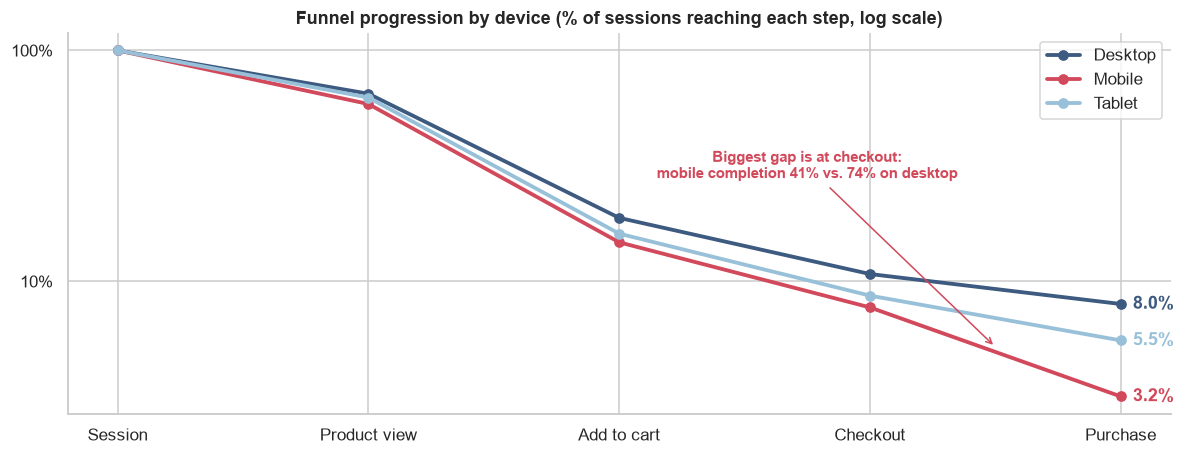

In [16]:
steps = ["sessions", "product_views", "add_to_carts", "checkouts", "purchases"]
labels = ["Session", "Product view", "Add to cart", "Checkout", "Purchase"]
fig, ax = plt.subplots(figsize=(11, 4.3))
for dev, color in [("Desktop", PRIMARY), ("Mobile", ALERT), ("Tablet", SECONDARY)]:
    vals = fd.loc[dev, steps] / fd.loc[dev, "sessions"] * 100
    ax.plot(labels, vals, marker="o", lw=2.5, color=color, label=dev)
    ax.annotate(f"{vals.iloc[-1]:.1f}%", (4, vals.iloc[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", color=color, fontweight="bold")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:g}%"))
ax.set(title="Funnel progression by device (% of sessions reaching each step, log scale)", ylabel="")
ax.legend()
ax.annotate("Biggest gap is at checkout:\nmobile completion 41% vs. 74% on desktop",
            xy=(3.5, 5.2), xytext=(2.75, 28), ha="center",
            arrowprops=dict(arrowstyle="->", color=ALERT), color=ALERT, fontsize=9.5, fontweight="bold")
fig.tight_layout()
save(fig, "05_funnel_by_device")
plt.show()

In [17]:
run(con, "06_funnel_analysis.sql", "lost_checkout_opportunity")

,mobile_checkouts,mobile_completion_pct,desktop_completion_pct,extra_orders_if_matched,est_revenue_opportunity
0,3343,41.2,74.2,1103.0,238869.0


Mobile and desktop shoppers behave similarly **up to checkout**, which points to the
checkout itself rather than lower purchase intent. **Only 41% of mobile checkouts complete,
against 74% on desktop.** Closing that gap would have produced roughly **1,100 additional
orders (≈ $240K)** in 2025 from traffic Cartwise already paid for.

In [18]:
run(con, "06_funnel_analysis.sql", "funnel_by_channel")

,traffic_channel,sessions,add_to_cart_pct,conversion_pct
0,Affiliate,5644,18.4,5.83
1,Organic Search,14038,18.4,5.68
2,Paid Search,15533,18.3,5.50
3,Email,6890,18.1,5.21
4,Referral,6898,17.1,4.94
5,Paid Social,20997,11.4,3.34


Paid Social traffic also converts worst at session level (3.3%, against 5–6% elsewhere).
Its add-to-cart rate is much lower, which points to lower purchase intent.

## 6. RFM customer segmentation

In [19]:
show_sql("07_rfm_segmentation.sql", "rfm_customers")

-- 07_rfm_segmentation.sql :: rfm_customers
WITH base AS (
    SELECT  customer_id,
            CAST(julianday('2026-01-01') - julianday(MAX(order_date)) AS INTEGER) AS recency_days,
            COUNT(*)                                                             AS frequency,
            ROUND(SUM(order_value), 2)                                           AS monetary
    FROM v_completed_orders
    GROUP BY customer_id
),
scored AS (
    SELECT  *,
            NTILE(5) OVER (ORDER BY recency_days DESC) AS r_score,   -- more recent = higher
            -- Most customers have 1-2 orders, so NTILE() would split identical
            -- frequencies into different scores. Fixed business thresholds instead:
            CASE WHEN frequency >= 6 THEN 5
                 WHEN frequency >= 4 THEN 4
                 WHEN frequency  = 3 THEN 3
                 WHEN frequency  = 2 THEN 2
                 ELSE 1 END                            AS f_score,
            NTILE(5) OVER (ORDER BY monetary)

In [20]:
seg = run(con, "07_rfm_segmentation.sql", "rfm_segment_summary")
seg

,segment,customers,pct_customers,revenue,pct_revenue,avg_recency_days,avg_orders,avg_revenue
0,Hibernating,3957,35.7,1035735.0,23.0,498.0,1.2,262.0
1,Champions,833,7.5,949884.0,21.1,53.0,5.3,1140.0
2,New & Promising,3065,27.7,852607.0,19.0,52.0,1.3,278.0
3,Loyal Customers,1138,10.3,837932.0,18.6,140.0,3.4,736.0
4,Needs Attention,1606,14.5,472740.0,10.5,218.0,1.4,294.0
5,At Risk (high value),471,4.3,348240.0,7.7,440.0,3.5,739.0


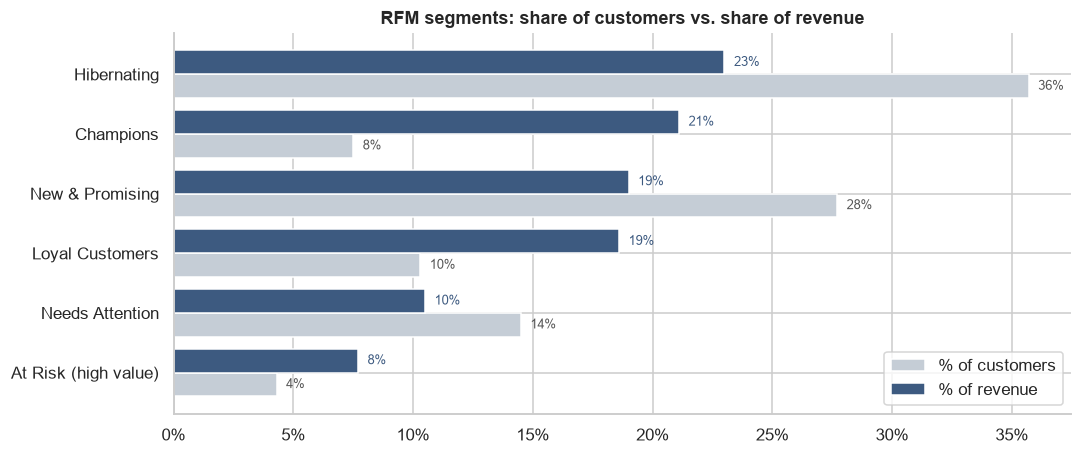

In [21]:
s = seg.set_index("segment").sort_values("pct_revenue")
fig, ax = plt.subplots(figsize=(10, 4.3))
y = np.arange(len(s))
ax.barh(y - 0.2, s["pct_customers"], height=0.4, color=MUTED, label="% of customers")
ax.barh(y + 0.2, s["pct_revenue"], height=0.4, color=PRIMARY, label="% of revenue")
ax.set_yticks(y, s.index)
ax.xaxis.set_major_formatter(pct)
for i, (pc, pr) in enumerate(zip(s["pct_customers"], s["pct_revenue"])):
    ax.text(pc + 0.4, i - 0.2, f"{pc:.0f}%", va="center", fontsize=8.5, color="#555")
    ax.text(pr + 0.4, i + 0.2, f"{pr:.0f}%", va="center", fontsize=8.5, color=PRIMARY)
ax.set_title("RFM segments: share of customers vs. share of revenue")
ax.legend(loc="lower right")
fig.tight_layout()
save(fig, "06_rfm_segments")
plt.show()

* **Champions** are 7.5% of customers but generate about 21% of revenue.
* **At Risk (high value)**: 471 customers who used to buy often (3.5 orders, ~$740 each)
  but have not purchased in about 15 months. They are the clearest win-back target.

## 7. Revenue concentration and category economics

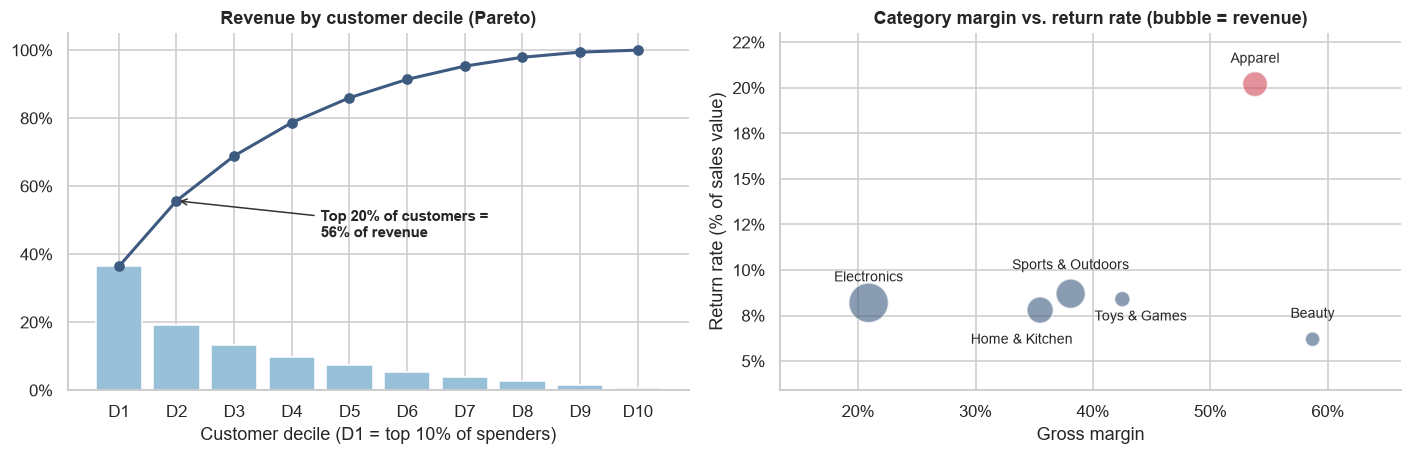

,category,net_revenue,gross_margin_pct,return_rate_pct,returned_value
0,Electronics,1678889.0,20.9,8.2,150397.0
1,Sports & Outdoors,923566.0,38.1,8.7,87917.0
2,Home & Kitchen,745252.0,35.5,7.8,62985.0
3,Apparel,666598.0,53.8,20.2,168696.0
4,Toys & Games,255296.0,42.5,8.4,23349.0
5,Beauty,227538.0,58.7,6.2,14926.0


In [22]:
conc = run(con, "08_product_and_concentration.sql", "revenue_concentration")
cat = run(con, "08_product_and_concentration.sql", "category_performance")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
ax = axes[0]
ax.bar(conc["decile"], conc["pct_revenue"], color=SECONDARY)
ax.plot(conc["decile"], conc["cumulative_pct_revenue"], color=PRIMARY, marker="o", lw=2)
ax.yaxis.set_major_formatter(pct)
ax.set_xticks(conc["decile"], [f"D{d}" for d in conc["decile"]])
ax.set(title="Revenue by customer decile (Pareto)", xlabel="Customer decile (D1 = top 10% of spenders)")
ax.annotate(f"Top 20% of customers =\n{conc.loc[1, 'cumulative_pct_revenue']:.0f}% of revenue",
            xy=(2, conc.loc[1, "cumulative_pct_revenue"]), xytext=(4.5, 45),
            arrowprops=dict(arrowstyle="->", color="#333"), fontsize=9.5, fontweight="bold")

ax = axes[1]
ax.scatter(cat["gross_margin_pct"], cat["return_rate_pct"], s=cat["net_revenue"] / 2500,
           color=[ALERT if r > 15 else PRIMARY for r in cat["return_rate_pct"]], alpha=0.6, edgecolor="white")
offsets = {"Sports & Outdoors": (0, 16), "Toys & Games": (12, -14), "Home & Kitchen": (-12, -22)}
for _, r in cat.iterrows():
    ax.annotate(r.category, (r.gross_margin_pct, r.return_rate_pct),
                xytext=offsets.get(r.category, (0, 14)), textcoords="offset points",
                ha="center", fontsize=9)
ax.xaxis.set_major_formatter(pct)
ax.yaxis.set_major_formatter(pct)
ax.set(title="Category margin vs. return rate (bubble = revenue)",
       xlabel="Gross margin", ylabel="Return rate (% of sales value)")
ax.margins(0.2)
fig.tight_layout()
save(fig, "07_concentration_and_categories")
plt.show()
cat

* Revenue is concentrated: the **top 20% of customers generate ~56% of revenue**, so
  retaining them matters more than acquiring one-time buyers.
* **Apparel** has the second-highest margin (54%) but a **20% return rate**, more than double
  any other category. About $169K of sales were returned, mostly erasing the margin
  advantage.

## 8. Recommendations

| Priority | Recommendation | Evidence | Expected impact |
|---|---|---|---|
| 1 | **Fix the mobile checkout.** Audit form length, payment options (add wallet pay) and page speed; A/B test a one-page checkout. | Mobile checkout completion 41% vs. 74% on desktop | ≈1,100 more orders and **≈$240K** per year at current traffic |
| 2 | **Rebalance acquisition budget from Paid Social towards Referral, Search and Email.** Judge channels on 12-month customer value, not cost per first order. | Paid Social: 30% of new customers, lowest 90-day repeat rate (31%) and 12-month value ($259 vs. $607 for Referral) | Higher LTV per marketing dollar |
| 3 | **Scale Cartwise Plus.** Offer it at checkout to first-time buyers, then confirm the effect with a holdout group. | 90-day repeat rate about 35% → 46% for post-launch cohorts | More repeat orders from customers already acquired |
| 4 | **Run a win-back campaign for "At Risk" high-value customers.** | 471 customers averaging $739 lifetime spend, inactive for about 15 months | Recovering 10–15% ≈ $35–50K |
| 5 | **Reduce Apparel returns** with better size guides, fit reviews and "true to size" indicators. | 20% return rate vs. 6–9% for other categories | Protect about $169K of returned sales |

**Next steps:** build these KPIs into a recurring dashboard and A/B test the mobile checkout
change before full rollout.

In [23]:
con.close()